#  Imports and Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw_listings.csv')

In [21]:
df.sample(10)

,name,url,price,mileage,location
1075,Chevy Camaro Ss,https://www.craigslist.org/view/d/san-ramon-ch...,10000,85000.0,eastbayarea
1560,2008 Lexus Es350 Es 350 Best Offer,https://www.craigslist.org/view/d/tracy-2008-l...,5950,166000.0,"Tracy,CA"
2275,"2003 Ford F150 King Cab, 8 Foot Bed, Lumber Ra...",https://www.craigslist.org/view/d/santa-cruz-2...,2550,242000.0,santacruz
195,1999 Land Rover Discovery Ii,https://www.craigslist.org/view/d/san-jose-199...,9800,150000.0,SanJose
959,"Extremely Low Miles 2004 Bmw 530I, Very Good C...",https://www.craigslist.org/view/d/san-jose-ext...,8500,55000.0,sanjosesouth
498,Austin Healey,https://www.craigslist.org/view/d/san-francisc...,6500,1.0,SanFrancisco
591,2001 Porsche Boxster S,https://www.craigslist.org/view/d/mill-valley-...,11000,94000.0,millvalley
172,"🔥 2017 Lexus Ct 200H Hybrid – Only 46,624 Mile...",https://www.craigslist.org/view/d/campbell-lex...,19300,46000.0,campbell
707,2012 Nissan Altima 96K Miles,https://www.craigslist.org/view/d/union-city-2...,5700,96000.0,fremont/unioncity/newark
2487,Subaru Forester Awd****Runs Good/Just Passed S...,https://www.craigslist.org/view/d/campbell-sub...,2295,200000.0,campbell


In [22]:
df.describe()

,price,mileage
count,2497.00000,2.495000e+03
mean,12119.05807,1.277157e+05
std,18217.30274,8.926125e+04
min,1.00000,1.000000e+00
25%,4500.00000,7.800000e+04
50%,8000.00000,1.200000e+05
75%,14900.00000,1.700000e+05
max,666666.00000,2.000000e+06


# EDA & Data Cleaning

### Feature Cleaning: Location

In [23]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [24]:
df.sample(10)

,name,url,price,mileage,location
1409,1986 Jeep Cj 7,https://www.craigslist.org/view/d/healdsburg-1...,20000,87000.0,healdsburg
2314,2012 Ford F250 Lariat 6.7L Crew Cab,https://www.craigslist.org/view/d/alamo-2012-f...,22000,157000.0,danville
1556,2011 Lexus Is 250 C - Low Miles And Great Cond...,https://www.craigslist.org/view/d/sausalito-20...,16000,74000.0,sausalito
1962,2010 Cadillac Cts Wagon – 3.6 Rwd Performance ...,https://www.craigslist.org/view/d/berkeley-201...,8000,112000.0,berkeley
861,2013 Toyota Sienna Le,https://www.craigslist.org/view/d/hayward-2013...,8500,176000.0,hayward
1343,1997 Toyota Land Cruiser (Fzj80) Collector’S ...,https://www.craigslist.org/view/d/san-francisc...,12500,375000.0,sunset
908,"2017 Subaru Forester 2.5I Awd, 108K, Mint!",https://www.craigslist.org/view/d/walnut-creek...,12900,108000.0,walnutcreek
2350,2002 Chevrolet Astro Van,https://www.craigslist.org/view/d/alameda-2002...,9500,92000.0,alameda
2439,1961 Vwbug,https://www.craigslist.org/view/d/brentwood-19...,20500,34000.0,brentwood
1613,2015 Bmw 328I Xdrive,https://www.craigslist.org/view/d/antioch-2015...,8900,141000.0,pittsburg


### Univariate Analysis & Outliers

In [25]:
print(df[['price', 'mileage']].describe())

              price       mileage
count    2497.00000  2.495000e+03
mean    12119.05807  1.277157e+05
std     18217.30274  8.926125e+04
min         1.00000  1.000000e+00
25%      4500.00000  7.800000e+04
50%      8000.00000  1.200000e+05
75%     14900.00000  1.700000e+05
max    666666.00000  2.000000e+06


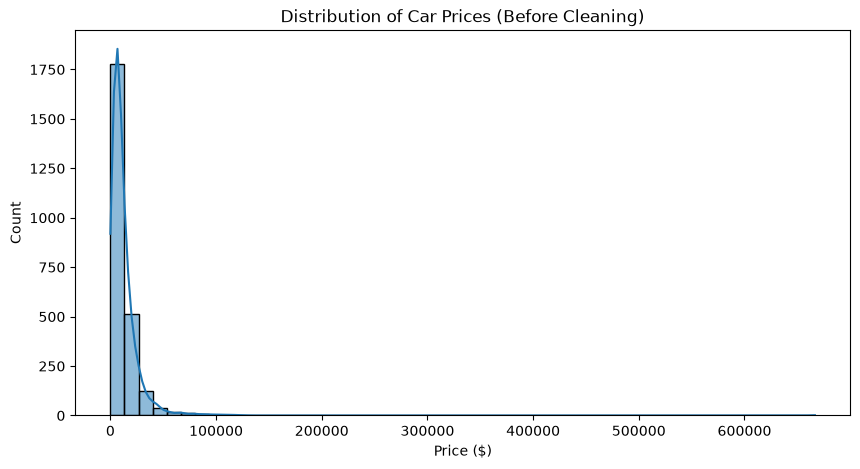

In [26]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

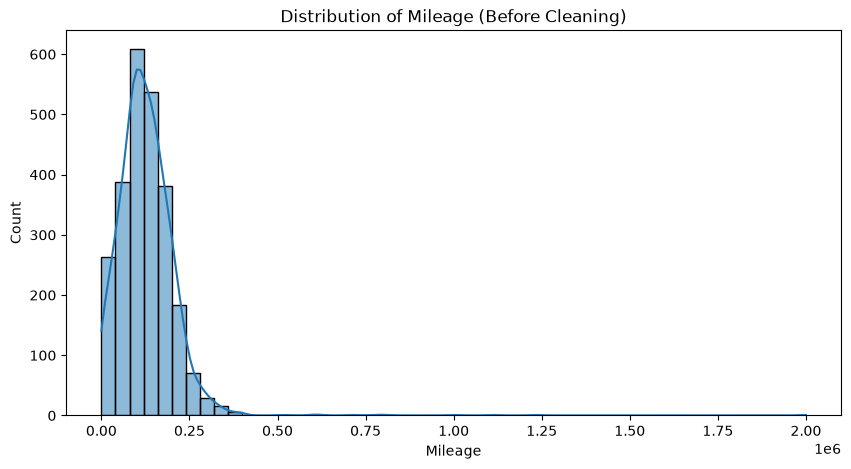

In [27]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [28]:
# 1. Define the realistic bounds for vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# 2. Filter the DataFrame
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE)
].copy()

# Drop any remaining rows where mileage or price might be NaN
df_clean = df_clean.dropna(subset=['price', 'mileage'])

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_clean)}")

# New mathematical summary
print(df_clean[['price', 'mileage']].describe())

Rows before trimming: 2497
Rows after trimming: 2377
              price        mileage
count   2377.000000    2377.000000
mean   11960.732857  122511.675221
std    11703.929795   62430.516387
min      800.000000     100.000000
25%     4850.000000   79000.000000
50%     8500.000000  120000.000000
75%    15000.000000  165000.000000
max    99999.000000  300000.000000


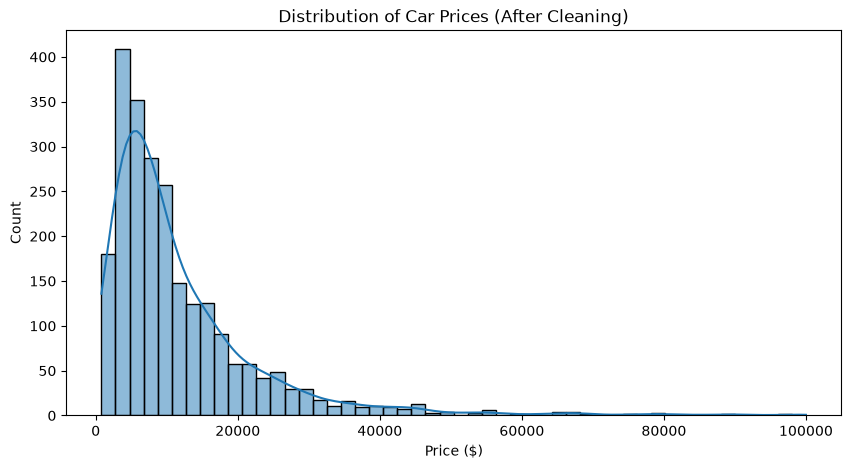

In [29]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

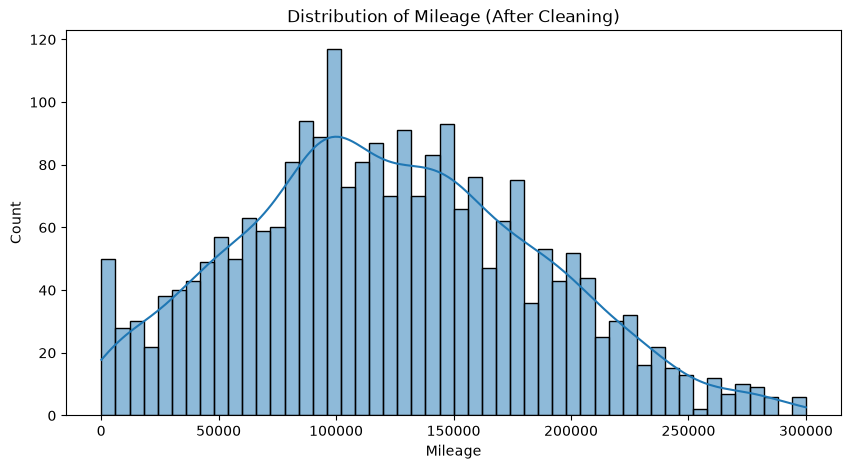

In [30]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [31]:
# 1. Define a list of common car manufacturers
manufacturers = [
    'Toyota', 'Honda', 'Ford', 'Chevrolet', 'Chevy', 'Nissan', 'BMW', 'Mercedes', 'Benz', 
    'Audi', 'Lexus', 'Subaru', 'Volkswagen', 'Vw', 'Hyundai', 'Kia', 'Mazda', 'Acura', 'Jeep', 
    'Dodge', 'Ram', 'GMC', 'Cadillac', 'Infiniti', 'Volvo', 'Mitsubishi', 'Mini',
    'Porsche', 'Tesla', 'Land Rover', 'Jaguar', 'Chrysler', 'Buick', 'Pontiac', 'Saturn'
]

In [32]:
def extract_make(title):
    # Lowercase the title to make matching case-insensitive
    title_lower = title.lower()
    
    # Loop through our list of manufacturers
    for make in manufacturers:
        # Check if the lowercased make is in the title
        if make.lower() in title_lower:
            return make.title() # Return it nicely formatted (e.g., "Honda")
            
    return None # If no manufacturer is found, return None

In [33]:
# 2. Apply the function to our 'name' column
df_clean['make'] = df_clean['name'].apply(extract_make)

print("Makes found:")
print(df_clean['make'].value_counts())

print("\nRows with missing Make:")
print(df_clean['make'].isnull().sum())

Makes found:
make
Toyota        326
Ford          264
Honda         222
Bmw           121
Mercedes      120
Nissan         91
Chevy          80
Chevrolet      78
Lexus          76
Subaru         73
Dodge          54
Audi           49
Jeep           47
Acura          47
Volkswagen     44
Hyundai        43
Gmc            38
Mazda          36
Kia            33
Vw             32
Ram            32
Mini           27
Volvo          24
Tesla          17
Porsche        17
Chrysler       16
Pontiac        15
Cadillac       14
Infiniti       13
Mitsubishi     12
Land Rover     11
Jaguar         10
Buick           9
Saturn          4
Benz            1
Name: count, dtype: int64

Rows with missing Make:
281


In [34]:
# Look at the ones it couldn't find to see if we missed any brands
missing_makes = df_clean[df_clean['make'].isnull()]
print("\nSample titles with missing makes:")
print(missing_makes['name'])


Sample titles with missing makes:
5       2019 Range Rover Sport Hse, Engine Disassemble...
6                                               Hummer H3
25                  2008 Mercury Grand Marquis Ls - $5800
42                                2007 Nissam Frontier Xe
46                                     1967 Citroen Diane
                              ...                        
2461                                        911 Carrera 4
2464                                        1989 Corvette
2467                              2020 F150 Xlt Sport 2Wd
2474             1-Owner 2013 Mbz Gl450 - Low 84.5K Miles
2494                       1998 Grand Marquis Project Car
Name: name, Length: 281, dtype: str


In [35]:
# Drop rows where we still couldn't find the make
df_clean = df_clean.dropna(subset=['make'])

print(f"Final clean dataset size: {len(df_clean)} rows")

Final clean dataset size: 2096 rows


In [36]:
df_clean

,name,url,price,mileage,location,make
0,2015 Buick Regal Premium Ii Turbo - Only 52K M...,https://www.craigslist.org/view/d/san-bruno-20...,9975,52000.0,sanbruno,Buick
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw
2,Volvo,https://www.craigslist.org/view/d/forestville-...,21500,78000.0,russianriver,Volvo
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota
...,...,...,...,...,...,...
2491,Bmw X5M Deal Awd 6 Cyl Trade With Motorcycle,https://www.craigslist.org/view/d/fremont-bmw-...,9900,125000.0,eastbayarea,Bmw
2492,Bmw X5 M Sport Great Deal Trade With Motorcycle,https://www.craigslist.org/view/d/fremont-bmw-...,5900,145000.0,eastbayarea,Bmw
2493,Bmw 430I Coupe - Private Seller,https://www.craigslist.org/view/d/los-gatos-bm...,16700,69000.0,losgatos,Bmw
2495,2013 Mazda 3 Hatch Back I Touring,https://www.craigslist.org/view/d/san-francisc...,6500,146000.0,potrerohill,Mazda


In [ ]:
# 1. Define a dictionary mapping Makes to their most popular models
car_models_dict = {
    'Toyota': ['Camry', 'Corolla', 'Prius', 'Sienna', 'Tacoma', 'Tundra', 'Rav4', 'Highlander', '4Runner', 'Avalon', 'Yaris', 'Sequoia', 'Matrix', 'Fj Cruiser', 'Venza'],
    'Honda': ['Civic', 'Accord', 'Cr-v', 'Crv', 'Odyssey', 'Pilot', 'Fit', 'Hr-v', 'Hrv', 'Element', 'Ridgeline', 'Insight', 'Passport', 'S2000'],
    'Ford': ['F150', 'F-150', 'F250', 'F-250', 'F350', 'F-350', 'Escape', 'Explorer', 'Focus', 'Fusion', 'Mustang', 'Edge', 'Transit', 'Ranger', 'Expedition', 'Taurus', 'Bronco', 'Flex'],
    'Chevrolet': ['Silverado', 'Equinox', 'Malibu', 'Cruze', 'Tahoe', 'Impala', 'Colorado', 'Camaro', 'Corvette', 'Suburban', 'Traverse', 'Spark', 'Sonic', 'Volt', 'Bolt'],
    'Nissan': ['Altima', 'Sentra', 'Rogue', 'Maxima', 'Murano', 'Pathfinder', 'Versa', 'Frontier', 'Titan', 'Armada', 'Leaf', '350Z', '370Z', 'Juke', 'Kicks'],
    'Bmw': ['328I', '335I', '325I', 'X5', 'X3', 'M3', 'M4', 'M5', '528I', '535I', '750Li', 'X1'],
    'Mercedes': ['C300', 'E350', 'Ml350', 'Glk350', 'S550', 'Gle', 'Glc', 'Gla', 'Sprinter', 'C63', 'Amg'],
    'Subaru': ['Outback', 'Forester', 'Impreza', 'Legacy', 'Crosstrek', 'Wrx', 'Brz', 'Ascent'],
    'Volkswagen': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle'],
    'Vw': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle'],
    'Lexus': ['Rx', 'Es', 'Is', 'Nx', 'Gx', 'Lx', 'Gs', 'Ls'],
    'Audi': ['A4', 'A6', 'Q5', 'Q7', 'A3', 'S4', 'Tt', 'Q3', 'S5'],
    'Jeep': ['Grand Cherokee', 'Wrangler', 'Cherokee', 'Compass', 'Renegade', 'Patriot', 'Gladiator'],
    'Hyundai': ['Elantra', 'Sonata', 'Tucson', 'Santa Fe', 'Accent', 'Kona', 'Palisade', 'Veloster'],
    'Kia': ['Optima', 'Sorento', 'Soul', 'Forte', 'Sportage', 'Telluride', 'Sedona', 'Rio'],
    'Mazda': ['Mazda3', 'Mazda6', 'Cx-5', 'Cx5', 'Cx-9', 'Cx9', 'Miata', 'Mx-5'],
    'Dodge': ['Charger', 'Challenger', 'Grand Caravan', 'Durango', 'Journey', 'Dart'],
    'Ram': ['1500', '2500', '3500', 'Promaster'],
    'Gmc': ['Sierra', 'Acadia', 'Terrain', 'Yukon', 'Canyon', 'Savana'],
    'Tesla': ['Model 3', 'Model Y', 'Model S', 'Model X', 'Cybertruck']
}

def extract_model(title, make):
    if pd.isna(make):
        return None
        
    title_lower = title.lower()
    
    # If we have a list of models for this make, check if they exist in the title
    if make in car_models_dict:
        for model in car_models_dict[make]:
            if model.lower() in title_lower:
                # Standardize names (e.g., make 'Cr-v' into 'Crv')
                return model.replace('-', '').title() 
                
    return None

# Apply the new function
df_clean['model'] = df_clean.apply(lambda row: extract_model_v2(row['name'], row['make']), axis=1)

# Drop rows where a legitimate model couldn't be found
df_clean = df_clean.dropna(subset=['model'])

In [38]:
# Apply the function
df_clean['model'] = df_clean.apply(lambda row: extract_model(row['name'], row['make']), axis=1)

# Drop rows where no model is found
df_clean = df_clean.dropna(subset=['model'])

In [39]:
# Check models
print(df_clean[['name', 'make', 'model']].sample(30))

                                                   name       make  \
1167                             2013 Bmw 328I 3 Series        Bmw   
1919              2013 Subaru Impreza Sport Premium Awd     Subaru   
1626             2010 Toyota Prius Hybrid – Clean Title     Toyota   
2054  2011 Mazda3 I – Runs And Drives – Mechanic Spe...      Mazda   
706                    2015 Honda Civic Exl - One Owner      Honda   
2080                       01 Toyota Camry 4Cyl Salvage     Toyota   
1904                       09 Jeep Wrangler Unlimited X       Jeep   
698                         2005 Toyota 4Runner Sr5 4Wd     Toyota   
1399  2003 Honda Odyssey Ex-L * 3Rd Row Seat * Dvd P...      Honda   
655                                   2006 Toyota Camry     Toyota   
2303  2016 Nissan 370Z Sport Tech – Brand New Engine...     Nissan   
786                                           Ford F150       Ford   
1753                  1994 Chevrolet 1500 W/T Silverado  Chevrolet   
2451  2006 Toyota Hi

In [40]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,model,year
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw,Gti,2012
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi,Tt,2014
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota,Tacoma,2011
7,2019 Nissan Rogue Sport Awd,https://www.craigslist.org/view/d/lafayette-20...,14000,75000.0,concord,Nissan,Rogue,2019
8,2024 Tesla Model 3 Long Range Awd Highland Ref...,https://www.craigslist.org/view/d/pleasanton-2...,36995,35000.0,danville,Tesla,Model 3,2024
...,...,...,...,...,...,...,...,...
2485,2008 Bmw 335I Coupe • 6-Speed Manual • Factory...,https://www.craigslist.org/view/d/albany-2008-...,11500,111000.0,albany,Bmw,335I,2008
2486,2011 Toyota Prius,https://www.craigslist.org/view/d/san-jose-201...,5900,150000.0,sanjosedowntown,Toyota,Prius,2011
2489,2008 Mazda Mazda3 S Touring,https://www.craigslist.org/view/d/san-jose-200...,7600,91000.0,sanjoseeast,Mazda,Mazda3,2008
2490,2014 Jeep Wrangler Sahara Jku (Rv Flat-Tow Ready),https://www.craigslist.org/view/d/redwood-city...,16995,98000.0,redwoodshores,Jeep,Wrangler,2014


In [ ]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                                                name  year  age
1                                        2012 Vw Gti  2012   14
3  2014 Audi A7 Prestige Quattro S Line | 3.0T Su...  2014   12
4   Modified 2011 Toyota Tacoma Trd Sport Double Cab  2011   15
7                        2019 Nissan Rogue Sport Awd  2019    7
8  2024 Tesla Model 3 Long Range Awd Highland Ref...  2024    2


In [42]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [43]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [44]:
# 1. Define Features (X) and Target (y) and perform train_test_split

X = df_clean[['age', 'make', 'model', 'mileage', 'location']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = ohe.fit_transform(X_train[['make', 'model', 'location']])
X_test_encoded = ohe.transform(X_test[['make', 'model', 'location']])

# Put the encoded arrays back into DataFrames so they have column names
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(), index=X_test.index)

# Drop the original text columns from X_train and X_test, keep only numbers (year, mileage)
X_train_num = X_train.drop(columns=['make', 'model', 'location'])
X_test_num = X_test.drop(columns=['make', 'model', 'location'])

# Combine the numerical columns and encoded columns together
X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)

print(f"Training data shape: {X_train_final.shape}")
print(f"Testing data shape: {X_test_final.shape}")

Training data shape: (1024, 311)
Testing data shape: (256, 311)


## Train the Model

In [46]:
# Diagnostic check: What columns is the model actually seeing?
print("Columns being fed to the model:")
print(X_train_final.columns.tolist())

print("\nFirst 3 rows of training data:")
X_train_final.head(3)

Columns being fed to the model:
['age', 'mileage', 'make_Audi', 'make_Bmw', 'make_Chevrolet', 'make_Dodge', 'make_Ford', 'make_Gmc', 'make_Honda', 'make_Hyundai', 'make_Jeep', 'make_Kia', 'make_Lexus', 'make_Mazda', 'make_Mercedes', 'make_Nissan', 'make_Ram', 'make_Subaru', 'make_Tesla', 'make_Toyota', 'make_Volkswagen', 'make_Vw', 'model_1500', 'model_2500', 'model_325I', 'model_328I', 'model_335I', 'model_350Z', 'model_4Runner', 'model_528I', 'model_535I', 'model_A3', 'model_A4', 'model_A6', 'model_Acadia', 'model_Accent', 'model_Accord', 'model_Altima', 'model_Amg', 'model_Armada', 'model_Avalon', 'model_Beetle', 'model_Bolt', 'model_Bronco', 'model_Brz', 'model_C300', 'model_Camaro', 'model_Camry', 'model_Challenger', 'model_Cherokee', 'model_Civic', 'model_Colorado', 'model_Compass', 'model_Corolla', 'model_Corvette', 'model_Crosstrek', 'model_Cruze', 'model_Crv', 'model_Cx5', 'model_Cx9', 'model_Dart', 'model_Durango', 'model_E350', 'model_Edge', 'model_Elantra', 'model_Element',

,age,mileage,make_Audi,make_Bmw,make_Chevrolet,make_Dodge,make_Ford,make_Gmc,make_Honda,make_Hyundai,...,"location_tracy,ca",location_twinpeaks,location_unioncity,location_vallejo,location_visitacionvalley,location_walnutcreek,location_watsonville,location_westmarin,location_westportal,location_willowglen
1769,12,156000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
523,23,82000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1031,13,116000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
# Tuned XGBoost Model
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8,     # Uses 80% of data per tree to prevent overfitting
    colsample_bytree=0.8, # Uses 80% of features per tree
    random_state=42
)   

# Train the model!
model.fit(X_train_final, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# Make predictions on our test set
predictions = model.predict(X_test_final)

# Calculate Mean Absolute Error (MAE) and R-Squared
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Visually compare actual vs predicted for the first 10 cars
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Make': X_test['make'].values[:10],
    'Model': X_test['model'].values[:10],
    'Mileage': X_test['mileage'].values[:10]
})
print("\nSample Predictions vs Actuals:")
print(comparison)

Model Performance:
Mean Absolute Error (MAE): $3,047.86
R-Squared (R2): 0.68

Sample Predictions vs Actuals:
   Actual_Price  Predicted_Price  Age       Make      Model   Mileage
0          6500             6991   11    Hyundai    Elantra  105000.0
1          2495             4046   22     Toyota     Matrix  198000.0
2         14500            11938    8     Subaru    Impreza   69000.0
3          4950            13451   63      Dodge       Dart   21000.0
4          4250             5406   16     Toyota      Camry  228000.0
5          3900             4142   17     Toyota      Prius  203000.0
6          8200             6428   13        Gmc      Yukon  144000.0
7         12900            12444    9     Toyota     Avalon  120000.0
8         27000            17908    8  Chevrolet  Silverado   73000.0
9          9500             8530   13     Subaru    Impreza  102000.0


# Export the model using Pickle

In [51]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

print("Model and Encoder saved successfully to the api/ folder!")

Model and Encoder saved successfully to the api/ folder!


In [52]:
# Save the exact column order from the final training dataframe
joblib.dump(X_train_final.columns.tolist(), '../api/model_columns.pkl')
print("Saved model_columns.pkl!")

Saved model_columns.pkl!
